# Signal Engine — v2.6
**General-purpose signal IC analysis and alpha combination framework**

Point at any asset universe and signal library via the Configuration cell.
The combination engine, regime conditioning, and mega-alpha run without modification.

**v2 → v2.1:** Weight gate, regime-aware weights, sign override map
**v2.1 → v2.2:** ε rank-normalization, full parameterization
**v2.2 → v2.3:** Cell 2.5 correlation diagnostic, STUDY_LOG, semis override findings
**v2.4 → v2.5:**
- Tier 6: FRED API integration — HY OAS spread, 10Y-2Y yield curve,
  CPI level, core CPI, 5Y breakeven inflation rate
- FRED replaces yfinance HYG/LQD proxy and TNX-IRX reconstruction
  with cleaner source data when FRED_API_KEY is set
- Graceful fallback to yfinance proxies if FRED key not provided
- CPI_Regime and CoreCPI_Change signals: monthly print feeds directly
  into daily signal — tomorrow's 8:30 AM CPI updates these automatically

**v2.3 → v2.4:**
- Tier 3: Short Interest signals (SI_Ratio, SI_DaysToCover, SI_Change_21d)
  Pulled from yfinance info + FINRA bi-monthly short interest data
- Tier 4: Earnings Estimate Revision signals (EPS_Revision_Dir, EPS_Surprise)
  Pulled from Financial Modeling Prep free API
- Tier 5: Credit Market signals (CreditSpread, CreditSpread_Change, YieldCurve_Slope)
  Pulled from yfinance (HYG, LQD, ^IRX, ^TNX) — no new vendor needed
- New config constants: FMP_API_KEY, SI_GATE, REVISION_LOOKBACK
- Cell 3.2: Fundamental & Credit data pull (separate from price data pull)
- Cell 3.3: Tier 3/4/5 signal construction functions
- Signal dict extended with 8 new signals
- KEEP_SIGNALS updated to include new signals after first IC run

**v2.5 → v2.6:**
- Bollinger_Pct_B removed from KEEP_SIGNALS and mega-alpha (redundant with Momentum_21d)
- Tier 7: Polygon.io integration — intraday VWAP slope (1-min bars, 2yr history)
- Tier 7: Polygon.io options P/C ratio — daily ticker-level put/call ratio
- Tier 8: Schwab Developer API stubs — live quote, streaming, account scaffolding
  (activate once Schwab app credentials are registered at developer.schwab.com)
- FMP API key updated
- API keys consolidated in Cell 0 for easy management
- Graceful fallback on all new data sources
- Polygon renamed to Massive.com — variable renamed to POLYGON_REST_API_KEY


## 0. Dependencies & Environment

In [1]:
!pip install yfinance pandas numpy scipy matplotlib seaborn requests fredapi polygon-api-client -q

from google.colab import drive
import os
drive.mount('/content/drive')

FOLDER = '/content/drive/MyDrive/factor-strength-study'
os.makedirs(FOLDER, exist_ok=True)

import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, rankdata
from sklearn.linear_model import LinearRegression
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

# ── API Keys — edit here only ─────────────────────────────────────────────────
FMP_API_KEY     = 'dQtyIChrt771K8IKgpm7C9DPRIqbZzVj'   # financialmodelingprep.com
FRED_API_KEY    = '739346a4b8a38dcf8ab2f6d4d3fef380'    # fred.stlouisfed.org
POLYGON_REST_API_KEY = 'Jfw_iVQvmga6eKI9aOSYleEsVfZtCGbZ'  # massive.com REST API key

# ── Schwab Developer API — stubs (not yet activated) ─────────────────────────
# Register app at: https://developer.schwab.com
# After registration you receive:
#   SCHWAB_CLIENT_ID     — your app's client ID
#   SCHWAB_CLIENT_SECRET — your app's client secret
# OAuth2 flow then provides an access token refreshed every 30 minutes.
# All Schwab calls below are scaffolded but gated behind SCHWAB_AVAILABLE.
SCHWAB_CLIENT_ID     = ''   # paste after developer.schwab.com registration
SCHWAB_CLIENT_SECRET = ''   # paste after developer.schwab.com registration
SCHWAB_REDIRECT_URI  = 'https://127.0.0.1'  # must match app registration

POLYGON_AVAILABLE = bool(POLYGON_REST_API_KEY)
SCHWAB_AVAILABLE  = bool(SCHWAB_CLIENT_ID and SCHWAB_CLIENT_SECRET)

print('Environment ready.')
print(f'Output folder: {FOLDER}')
print(f'FMP API:     {"set" if FMP_API_KEY else "NOT SET"}')
print(f'FRED API:    {"set" if FRED_API_KEY else "NOT SET"}')
print(f'Massive REST API: {"set" if POLYGON_REST_API_KEY else "NOT SET — paste key to enable Tier 7"}')
print(f'Schwab API:  {"NOT SET — register at developer.schwab.com" if not SCHWAB_AVAILABLE else "set"}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 6.1 MB/s eta 0:00:00
Mounted at /content/drive
Environment ready.
Output folder: /content/drive/MyDrive/factor-strength-study
FMP API:     set
FRED API:    set
Massive REST API: set
Schwab API:  NOT SET — register at developer.schwab.com


## 1. Configuration

In [2]:
# =============================================================================
# CONFIGURATION — edit this cell only when switching asset universes
# =============================================================================

# --- Study log ---
# Every universe you have run. Switch by changing STUDY_NAME below.
STUDY_LOG = {
    # ── Photonics ─────────────────────────────────────────────────────────────
    'photonics': [
        'IPGP', 'LITE', 'AEHR', 'COHR', 'AAOI'
        ,
    ],
    # ── Thesis 1: Power Grid & Grid Modernization ─────────────────────────────
    'power-grid': [
        'ETN',  'EMR',  'HUBB', 'GEV',
        'PWR',  'MYR',  'AES',  'AME',
    ],

    # ── Thesis 2: AI Compute & Data Centers ──────────────────────────────────
    'ai-compute-silicon': [
        'NVDA', 'AMD',  'AVGO', 'MRVL',
    ],
    'ai-dc-infrastructure': [
        'VRT',  'SMCI', 'AAON', 'EQIX', 'DLR',
    ],

    # ── Thesis 3: Defense Technology & Rearmament ─────────────────────────────
    'defense-tech': [
        'LMT',  'RTX',  'NOC',  'LHX',
        'KTOS', 'AVAV', 'PLTR', 'BAESY',
    ],

    # ── Thesis 4: Nuclear Energy ──────────────────────────────────────────────
    'nuclear-operators': [
        'CEG',  'VST',  'ETR',  'BWXT',
    ],
    'uranium-supply': [
        'CCJ',  'UEC',  'NXE',  'URA',
    ],

    # ── Thesis 5: Semiconductor Supply Chain ──────────────────────────────────
    'semi-supply-chain': [
        'AMAT', 'LRCX', 'KLAC', 'ASML',
        'AMKR', 'ENTG', 'MKSI', 'COHU',
    ],

    # ── Thesis 6: Autonomous & Robotic Systems ────────────────────────────────
    'autonomous-robotics': [
        'ROK',  'BRKS', 'KTOS', 'AVAV',
        'QCOM', 'ABB',
    ],

    # ── Thesis 7: Sovereign AI ────────────────────────────────────────────────
    # Heterogeneous — run correlation diagnostic first
    'sovereign-ai': [
        'EQIX', 'NVDA', 'SMCI', 'ASTS', 'VSAT',
    ],

    # ── Watch list (pre-revenue / low float — not engine-ready) ──────────────
    'watch-speculative': [
        'OKLO', 'NNE',  'RCAT', 'MVIS', 'ACHR',
    ],

}

# --- Active study (change this line to switch universes) ---
STUDY_NAME = 'autonomous-robotics'
UNIVERSE   = STUDY_LOG[STUDY_NAME]

# --- Macro regime tickers ---
# Always include VIX and TNX. Add sector overlays as needed.
MACRO_TICKERS = ['^VIX', '^SOX', '^TNX', 'USO', '^GSPC', 'QQQ']

# --- Drive output folder ---
FOLDER = f'/content/drive/MyDrive/factor-strength-study/'

# --- Data range ---
START = '2022-01-01'
END   = None  # None = today

# --- Forward return horizons (trading days) ---
HORIZONS = [1, 3, 5, 10, 21]

# --- Signal construction windows ---
VOL_WINDOW  = 10
SMA_WINDOW  = 200
EMA_FAST    = 9
EMA_SLOW    = 21
BB_WINDOW   = 20
BB_STD      = 2.0

# --- Combination engine ---
D_LOOKBACK    = 21    # Step 8 rolling window for expected return
VIX_THRESHOLD = 20.0  # VIX above = risk-off regime
TNX_THRESHOLD = 4.5   # TNX above = high-rate regime (%)

# --- Universe correlation gate (Cell 2.5) ---
CORR_GATE   = 0.85   # pairs above this flagged redundant
CORR_WINDOW = 63     # trading days for recent correlation (~3 months)

# --- Culling thresholds ---
IC_MIN   = 0.03
CORR_MAX = 0.70

# --- Approved signals ---
KEEP_SIGNALS = [
    'YieldCurve_Slope',   # NEW — top signal, macro driven
    'SMA200_Distance',    # mean reversion, consistent
    'CreditSpread',       # NEW — risk appetite proxy
    'Volume_Surge',       # short-horizon, news-driven
    'VIX_Regime',         # filter
    'Momentum_21d',       # weak but keep for now
    'Bollinger_Pct_B',    # keep, 50% sig
]

# --- Ticker-signal sign overrides ---
# Clear when switching to a new universe.
# Run engine once, read regime_conditional_ic.csv, then populate.
# Overrides only fire for tickers present in UNIVERSE.
TICKER_SIGNAL_OVERRIDES = {
    # Photonics study
    # LITE SMA200: momentum continuation active (IC=+0.263), reverts risk_off (IC=-0.495)
    ('SMA200_Distance', 'LITE', 'risk_off'): -1,

    # Semis study (v2.3)
    # SMA200 uniformly bearish for large-cap semis. Mean IC=-0.177 across universe.
    ('SMA200_Distance', 'NVDA', 'active'): -1,
    ('SMA200_Distance', 'AMD',  'active'): -1,
    ('SMA200_Distance', 'AVGO', 'active'): -1,
    ('SMA200_Distance', 'MRVL', 'active'): -1,
    ('SMA200_Distance', 'QCOM', 'active'): -1,
}

# --- Override evidence (reference only, not used in computation) ---
OVERRIDE_NOTES = {
    ('SMA200_Distance', 'LITE', 'risk_off'): {
        'IC_active': +0.263, 'IC_riskoff': -0.495,
        'source': 'photonics v2.1',
        'note': 'Structural uptrend = continuation active; reverts at TNX>=4.5%',
    },
    ('SMA200_Distance', 'NVDA', 'active'): {
        'IC_vix_low': +0.068, 'IC_vix_high': -0.274,
        'source': 'semis v2.3',
        'note': 'Post-peak mean reversion in sample',
    },
    ('SMA200_Distance', 'AVGO', 'active'): {
        'IC_vix_low': -0.267, 'IC_vix_high': -0.453,
        'source': 'semis v2.3',
        'note': 'Strongest reversion in semis, consistent both regimes',
    },
    ('SMA200_Distance', 'MRVL', 'active'): {
        'IC_vix_low': -0.346, 'IC_vix_high': -0.080,
        'source': 'semis v2.3',
        'note': 'Strong active regime; risk-off effect smaller sample',
    },
    ('SMA200_Distance', 'AMD',  'active'): {
        'IC_vix_low': -0.054, 'IC_vix_high': -0.329,
        'source': 'semis v2.3',
        'note': 'Directionally consistent; clearer in risk-off',
    },
    ('SMA200_Distance', 'QCOM', 'active'): {
        'IC_vix_low': -0.022, 'IC_vix_high': -0.355,
        'source': 'semis v2.3',
        'note': 'Persistent negative mega-alpha; sector rotation signal',
    },
}

# --- Tier 3: Short Interest ---
# SI data from yfinance .info (point-in-time snapshot, updated ~monthly)
# Used for SI_Ratio signal. Set SI_GATE to flag high short interest names.
SI_GATE = 0.10   # >10% of float short = elevated short interest

# --- Tier 4: Earnings Estimate Revisions ---
# Free API key from financialmodelingprep.com (register for free tier)
# Free tier: 250 calls/day — sufficient for up to ~25 tickers
# Leave empty string to skip FMP signals gracefully
FMP_API_KEY     = 'dQtyIChrt771K8IKgpm7C9DPRIqbZzVj'
REVISION_LOOKBACK = 63  # trading days to look back for revision trend

# --- Tier 5: Credit Market signals ---
# Pulled from yfinance — no new vendor needed
# HYG = iShares HY Bond ETF, LQD = iShares IG Bond ETF
# Credit spread = HYG yield - LQD yield (proxied by price ratio trend)
CREDIT_TICKERS = ['HYG', 'LQD', '^IRX']  # HY, IG, 3-month T-bill

# --- Tier 6: FRED API ---
# Free API key at fred.stlouisfed.org — takes 30 seconds to register.
# Replaces yfinance HYG/LQD proxy with cleaner source data.
# Also pulls CPI series for tomorrow's release read.
FRED_API_KEY = '739346a4b8a38dcf8ab2f6d4d3fef380'

# FRED series used in signal construction:
#   BAMLH0A0HYM2  — ICE BofA HY OAS spread (daily, cleaner than HYG/LQD)
#   T10Y2Y        — 10Y minus 2Y yield curve slope (daily)
#   CPIAUCSL      — CPI All Items (monthly, for CPI regime signal)
#   CPILFESL      — Core CPI ex food & energy (monthly)
#   T5YIE         — 5Y breakeven inflation rate (daily, market-implied inflation)
FRED_SERIES = {
    'HY_OAS'       : 'BAMLH0A0HYM2',   # replaces HYG/LQD proxy
    'YieldCurve'   : 'T10Y2Y',          # replaces reconstructed TNX-IRX
    'CPI'          : 'CPIAUCSL',        # monthly CPI level
    'CoreCPI'      : 'CPILFESL',        # monthly core CPI
    'Breakeven5Y'  : 'T5YIE',          # daily 5Y inflation breakeven
}


# --- Tier 7: Polygon.io ---
# Free tier: unlimited daily OHLCV (2003+), 2yr minute bars (15min delayed live)
# Used for: intraday VWAP slope (IC backtest), P/C ratio snapshot
# Get key at: massive.com (formerly polygon.io)
# Keys now set in Cell 0 — POLYGON_REST_API_KEY imported automatically
MASSIVE_BASE       = 'https://api.polygon.io'
VWAP_LOOKBACK_DAYS = 480    # trading days of 1-min data to pull (~2yr free tier max)
VWAP_SLOPE_WINDOW  = 78     # bars for VWAP slope (78 x 5min ≈ 1 session)
PC_RATIO_LOOKBACK  = 252    # trading days of daily P/C ratio history

# --- Tier 8: Schwab Developer API (stubs — not yet activated) ---
# Keys set in Cell 0. All calls below are gated behind SCHWAB_AVAILABLE.
# Schwab provides: real-time Level 1 quotes, streaming, account data
# Does NOT provide: historical options data (use Polygon for IC backtest)
SCHWAB_BASE        = 'https://api.schwabapi.com/marketdata/v1'
SCHWAB_AUTH_URL    = 'https://api.schwabapi.com/v1/oauth/authorize'
SCHWAB_TOKEN_URL   = 'https://api.schwabapi.com/v1/oauth/token'

# --- Derived constants (do not edit below this line) ---
ALL_TICKERS = UNIVERSE + MACRO_TICKERS + CREDIT_TICKERS
PHOTONICS   = UNIVERSE  # backward-compat alias

import os
os.makedirs(FOLDER, exist_ok=True)

print(f'Study:    {STUDY_NAME}')
print(f'Universe: {UNIVERSE}')
print(f'N:        {len(UNIVERSE)}')
print(f'Output:   {FOLDER}')
active_ov = {k: v for k, v in TICKER_SIGNAL_OVERRIDES.items() if k[1] in UNIVERSE}
if active_ov:
    print(f'Active overrides ({len(active_ov)}):')
    for k, v in active_ov.items():
        print(f'  {k}: {v:+d}')
else:
    print('Active overrides: none (expected for new universe)')
print('Config set.')


Study:    photonics
Universe: ['IPGP', 'LITE', 'AEHR', 'COHR', 'AAOI']
N:        5
Output:   /content/drive/MyDrive/factor-strength-study/
Active overrides (1):
  ('SMA200_Distance', 'LITE', 'risk_off'): -1
Config set.


## 2. Data Pull

In [3]:
raw = yf.download(ALL_TICKERS, start=START, end=END,
                  auto_adjust=True, progress=False)

close  = raw['Close'].copy()
volume = raw['Volume'].copy()

# Drop NaN-named columns (yfinance failed to resolve ticker)
nan_cols = [c for c in close.columns if pd.isna(c)]
if nan_cols:
    print(f'Dropping {len(nan_cols)} NaN-named column(s)')
    close  = close.drop(columns=nan_cols)
    volume = volume.drop(columns=nan_cols)

# Drop columns that resolved but returned no price data
empty_cols = close.columns[close.isna().all()].tolist()
if empty_cols:
    print(f'Dropping empty columns: {empty_cols}')
    close  = close.drop(columns=empty_cols)
    volume = volume.drop(columns=empty_cols)

# Rename macro tickers
rename = {'^VIX':'VIX','^SOX':'SOX','^TNX':'TNX',
          '^GSPC':'SPX','^IRX':'IRX'}
close  = close.rename(columns=rename)
volume = volume.rename(columns=rename)

# Rebuild UNIVERSE to only tickers that loaded
UNIVERSE  = [t for t in UNIVERSE if t in close.columns]
PHOTONICS = UNIVERSE  # keep alias in sync

missing = [t for t in STUDY_LOG[STUDY_NAME] if t not in close.columns]
if missing:
    print(f'WARNING — tickers not loaded: {missing}')

print(f'Shape:    {close.shape}')
print(f'Range:    {close.index[0].date()} → {close.index[-1].date()}')
print(f'Universe: {UNIVERSE}  (n={len(UNIVERSE)})')
close.tail(2)


Shape:    (1071, 14)
Range:    2022-01-03 → 2026-04-10
Universe: ['IPGP', 'LITE', 'AEHR', 'COHR', 'AAOI']  (n=5)


Ticker,AAOI,AEHR,COHR,HYG,IPGP,LITE,LQD,QQQ,USO,SPX,IRX,SOX,TNX,VIX
Date,,,,,,,,,,,,,,
2026-04-09,133.300003,68.860001,284.170013,80.279999,124.379997,894.130005,109.489998,610.190002,126.959999,6824.660156,3.588,8689.530273,4.293,19.49
2026-04-10,150.600006,70.430000,307.500000,79.959999,127.320000,897.299988,109.199997,611.070007,124.820000,6816.890137,3.593,8889.828125,4.317,19.23


## 2.5 Universe Correlation Diagnostic

Before any signal work, check whether the universe contains redundant tickers.

The combination engine IR scales with √N_eff where N_eff accounts for cross-ticker
correlations. Pairs with ρ > CORR_GATE (default 0.85) contribute near-zero independent
information — they inflate N without improving diversification.

**Run this cell after every universe change before proceeding to signals.**
Red boxes = redundant pairs. Consider dropping the lower-liquidity name from each pair,
or splitting into sub-universes grouped by business model.

=== Universe Correlation Diagnostic ===
N tickers : 5
N_eff     : 2.24  (44.8% of max)
Window    : 63 trading days
Gate      : rho > 0.85

Ticker_A Ticker_B  Corr_Recent  Corr_Full     Flag
    LITE     COHR        0.748       0.75 ELEVATED

Run full universe for overview, then re-run on sub-clusters.


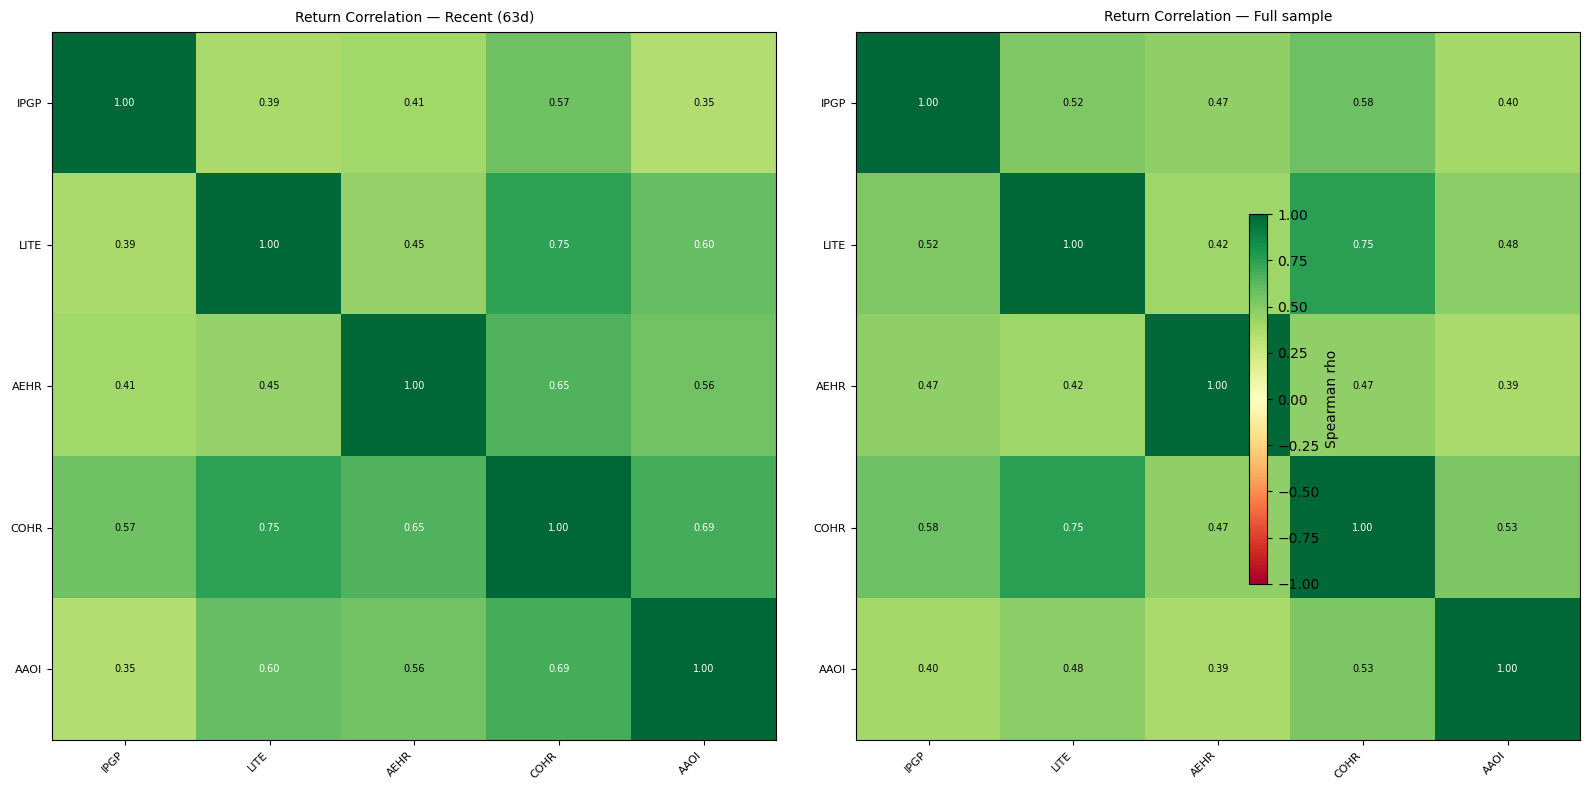

Saved: universe_correlation.png
Exported: universe_correlation_flags.csv, universe_correlation_recent.csv


In [4]:
# ── Cell 2.5: Universe Correlation Diagnostic (v2.3) ────────────────────────

ret = close[UNIVERSE].pct_change().dropna()
ret_recent = ret.iloc[-CORR_WINDOW:]
corr_recent = ret_recent.corr(method='spearman')
corr_full   = ret.corr(method='spearman')

N = len(UNIVERSE)

# N_effective from recent correlation matrix
N_eff     = round(N**2 / (corr_recent.values**2).sum(), 2)
N_eff_pct = round(N_eff / N * 100, 1)

# Flag pairs
flag_rows = []
for i, t1 in enumerate(UNIVERSE):
    for t2 in UNIVERSE[i+1:]:
        rho_r = corr_recent.loc[t1, t2]
        rho_f = corr_full.loc[t1, t2]
        if abs(rho_r) > CORR_GATE:
            flag = 'REDUNDANT'
        elif abs(rho_r) > 0.70:
            flag = 'ELEVATED'
        else:
            continue
        flag_rows.append({
            'Ticker_A': t1, 'Ticker_B': t2,
            'Corr_Recent': round(rho_r, 3),
            'Corr_Full':   round(rho_f, 3),
            'Flag': flag,
        })

flag_df = pd.DataFrame(flag_rows) if flag_rows else pd.DataFrame(
    columns=['Ticker_A','Ticker_B','Corr_Recent','Corr_Full','Flag'])

print('=== Universe Correlation Diagnostic ===')
print(f'N tickers : {N}')
print(f'N_eff     : {N_eff}  ({N_eff_pct}% of max)')
print(f'Window    : {CORR_WINDOW} trading days')
print(f'Gate      : rho > {CORR_GATE}')
print()
if flag_df.empty:
    print('No redundant pairs. Universe is well-diversified.')
else:
    print(flag_df.to_string(index=False))

# Advice
print()
if N_eff_pct < 40:
    print('CRITICAL: N_eff below 40%. Universe too correlated for reliable pooled IC.')
    print('Split into sub-universes of 5-8 names grouped by business model.')
elif N_eff_pct < 60:
    print('WARNING: Moderate redundancy. Sub-universe analysis recommended.')
    print('Run full universe for overview, then re-run on sub-clusters.')
elif N_eff_pct < 75:
    print('CAUTION: Some redundancy. Flagged pairs worth reviewing.')
else:
    print('Universe diversity acceptable for pooled analysis.')

# Heatmap
cell_sz = max(0.45, min(0.65, 8.0 / N))
fig_sz  = max(8, int(N * cell_sz) + 2)

fig, axes = plt.subplots(1, 2, figsize=(fig_sz * 2, fig_sz))
for ax, mat, title in [
    (axes[0], corr_recent, f'Recent ({CORR_WINDOW}d)'),
    (axes[1], corr_full,   'Full sample'),
]:
    im = ax.imshow(mat.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(UNIVERSE, rotation=45, ha='right',
                       fontsize=max(5, 9 - N//5))
    ax.set_yticklabels(UNIVERSE, fontsize=max(5, 9 - N//5))
    ax.set_title(f'Return Correlation — {title}', fontsize=10, pad=8)
    for i in range(N):
        for j in range(N):
            v = mat.values[i, j]
            txt_color = 'white' if abs(v) > 0.6 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=max(4, 7 - N//6), color=txt_color)
    # Red boxes on redundant pairs
    for _, row in flag_df[flag_df['Flag'] == 'REDUNDANT'].iterrows():
        r = UNIVERSE.index(row['Ticker_A'])
        c = UNIVERSE.index(row['Ticker_B'])
        for ri, ci in [(r, c), (c, r)]:
            rect = plt.Rectangle((ci-0.5, ri-0.5), 1, 1,
                                  fill=False, edgecolor='red', linewidth=2.5)
            ax.add_patch(rect)

plt.colorbar(im, ax=axes.tolist(), shrink=0.6, label='Spearman rho')
plt.tight_layout()
plt.savefig(f'{FOLDER}/universe_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: universe_correlation.png')

# Export
flag_df.to_csv(f'{FOLDER}/universe_correlation_flags.csv', index=False)
corr_recent.to_csv(f'{FOLDER}/universe_correlation_recent.csv')
print('Exported: universe_correlation_flags.csv, universe_correlation_recent.csv')


## 3.2 Fundamental & Credit Data Pull

Pulls three additional data layers:
- **Short interest** from yfinance `.info` (monthly snapshot per ticker)
- **Earnings estimate revisions** from Financial Modeling Prep API (requires free API key)
- **Credit market data** from yfinance (HYG, LQD, ^IRX — no vendor needed)

If `FMP_API_KEY` is empty, FMP signals are skipped gracefully and flagged in output.

In [5]:
# ── Cell 3.2: Fundamental, Credit & FRED Data Pull ─────────────────────────

# ── Short Interest (yfinance .info snapshot) ─────────────────────────────────
print('Pulling short interest data...')
si_data = {}
for t in UNIVERSE:
    try:
        info = yf.Ticker(t).info
        si_data[t] = {
            'sharesShort'         : info.get('sharesShort', np.nan),
            'sharesOutstanding'   : info.get('sharesOutstanding', np.nan),
            'shortRatio'          : info.get('shortRatio', np.nan),
            'shortPercentOfFloat' : info.get('shortPercentOfFloat', np.nan),
            'floatShares'         : info.get('floatShares', np.nan),
        }
        pct   = si_data[t]['shortPercentOfFloat']
        ratio = si_data[t]['shortRatio']
        pct_str   = f'{pct*100:.1f}%' if pct and not np.isnan(pct) else 'n/a'
        ratio_str = f'{ratio:.1f}d' if ratio and not np.isnan(ratio) else 'n/a'
        print(f'  {t}: SI%={pct_str}  DaysToCover={ratio_str}')
    except Exception as e:
        si_data[t] = {}
        print(f'  {t}: SI failed ({e})')

si_df = pd.DataFrame(si_data).T
print()

# ── Earnings Estimate Revisions (FMP API) ────────────────────────────────────
print('Pulling earnings estimate revisions...')
fmp_data = {}
FMP_AVAILABLE = bool(FMP_API_KEY)
if FMP_AVAILABLE:
    base = 'https://financialmodelingprep.com/api/v3'
    for t in UNIVERSE:
        try:
            r  = requests.get(f'{base}/analyst-estimates/{t}?limit=8&apikey={FMP_API_KEY}', timeout=10)
            r2 = requests.get(f'{base}/earnings-surprises/{t}?apikey={FMP_API_KEY}', timeout=10)
            fmp_data[t] = {
                'estimates': r.json()[:4] if isinstance(r.json(), list) else [],
                'surprises': r2.json()[:4] if isinstance(r2.json(), list) else [],
            }
            print(f'  {t}: {len(fmp_data[t]["estimates"])} estimates, {len(fmp_data[t]["surprises"])} surprises')
        except Exception as e:
            fmp_data[t] = {'estimates': [], 'surprises': []}
            print(f'  {t}: FMP failed ({e})')
else:
    print('  FMP_API_KEY not set — skipping. Get free key at financialmodelingprep.com')
    for t in UNIVERSE:
        fmp_data[t] = {'estimates': [], 'surprises': []}
print()

# ── FRED Data Pull (replaces yfinance credit proxies) ────────────────────────
print('Pulling FRED data...')
FRED_AVAILABLE = bool(FRED_API_KEY)
fred_data = {}

if FRED_AVAILABLE:
    fred = Fred(api_key=FRED_API_KEY)
    for name, series_id in FRED_SERIES.items():
        try:
            s = fred.get_series(series_id, observation_start=START)
            fred_data[name] = s
            print(f'  {name} ({series_id}): {len(s)} observations, '
                  f'latest={s.index[-1].date()} val={s.iloc[-1]:.4f}')
        except Exception as e:
            fred_data[name] = pd.Series(dtype=float)
            print(f'  {name}: failed ({e})')
else:
    print('  FRED_API_KEY not set — using yfinance proxies for credit signals.')
    print('  Get free key at fred.stlouisfed.org and paste into config.')
    for name in FRED_SERIES:
        fred_data[name] = pd.Series(dtype=float)

# ── Credit fallback: yfinance HYG/LQD if FRED not available ─────────────────
CREDIT_TICKERS = ['HYG', 'LQD']
print()
print('Pulling yfinance credit fallback (HYG, LQD)...')
try:
    credit_raw   = yf.download(CREDIT_TICKERS, start=START, end=END,
                               auto_adjust=True, progress=False)
    credit_close = credit_raw['Close'].copy()
    nan_credit   = [c for c in credit_close.columns if pd.isna(c)]
    credit_close = credit_close.drop(columns=nan_credit)
    credit_rename = {'^IRX': 'IRX'}
    credit_close  = credit_close.rename(columns=credit_rename)
    print(f'  Credit fallback shape: {credit_close.shape}')
except Exception as e:
    credit_close = pd.DataFrame(index=close.index)
    print(f'  Credit fallback failed: {e}')

print()
print('Data pull complete.')
print(f'  FRED available: {FRED_AVAILABLE}')
print(f'  FMP available:  {FMP_AVAILABLE}')


Pulling short interest data...
  IPGP: SI%=15.3%  DaysToCover=2.8d
  LITE: SI%=18.0%  DaysToCover=2.0d
  AEHR: SI%=15.3%  DaysToCover=2.6d
  COHR: SI%=5.1%  DaysToCover=1.2d
  AAOI: SI%=13.7%  DaysToCover=1.0d

Pulling earnings estimate revisions...
  IPGP: 0 estimates, 0 surprises
  LITE: 0 estimates, 0 surprises
  AEHR: 0 estimates, 0 surprises
  COHR: 0 estimates, 0 surprises
  AAOI: 0 estimates, 0 surprises

Pulling FRED data...
  HY_OAS (BAMLH0A0HYM2): 1129 observations, latest=2026-04-09 val=2.9000
  YieldCurve (T10Y2Y): 1115 observations, latest=2026-04-10 val=0.5000
  CPI: failed (Internal Server Error)
  CoreCPI: failed (Internal Server Error)
  Breakeven5Y (T5YIE): 1115 observations, latest=2026-04-10 val=2.5800

Pulling yfinance credit fallback (HYG, LQD)...
  Credit fallback shape: (1071, 2)

Data pull complete.
  FRED available: True
  FMP available:  True


## 3.4 Tier 7 & 8 — Polygon + Schwab Data Pull

**Tier 7 — Polygon.io (free tier)**
- `VWAP_Slope`: intraday VWAP slope from 1-minute bars. Measures institutional accumulation direction within session.
- `PC_Ratio`: daily put/call ratio per ticker. Options flow signal. Free tier = current snapshot; historical via paid tier.

**Tier 8 — Schwab Developer API (stubs)**
- `schwab_quote()`: real-time Level 1 quote for a ticker
- `schwab_stream()`: streaming quote scaffold (activate after OAuth setup)
- All Schwab calls gated behind `SCHWAB_AVAILABLE` — safe to run before registration.

Polygon IC backtest uses 1-minute bars pulled once and cached to Drive.
Schwab calls are live-only — no historical data available for options.


In [6]:
# ── Cell 3.4: Polygon + Schwab Data Pull (v2.6) ──────────────────────────────

import time
from datetime import datetime, timedelta

# ── Tier 7A: Polygon — Intraday VWAP Slope ───────────────────────────────────
# Uses 1-minute aggregate bars to compute VWAP slope per ticker per day.
# VWAP slope = linear regression slope of (price - VWAP) over last N bars.
# Positive slope = price trending above VWAP = institutional accumulation signal.

vwap_slope_data = {}   # ticker → pd.Series(date → slope)
pc_ratio_data   = {}   # ticker → pd.Series(date → put/call ratio)

if POLYGON_AVAILABLE:
    print('=== Tier 7: Polygon.io Data Pull ===')
    from polygon import RESTClient
    poly = RESTClient(api_key=POLYGON_REST_API_KEY)

    end_dt   = datetime.today()
    start_dt = end_dt - timedelta(days=int(VWAP_LOOKBACK_DAYS * 1.4))  # buffer for weekends
    start_str = start_dt.strftime('%Y-%m-%d')
    end_str   = end_dt.strftime('%Y-%m-%d')

    for t in UNIVERSE:
        print(f'  Pulling 1-min bars: {t}...', end=' ')
        try:
            bars = []
            for agg in poly.list_aggs(
                ticker=t,
                multiplier=1,
                timespan='minute',
                from_=start_str,
                to=end_str,
                adjusted=True,
                limit=50000,
            ):
                bars.append({
                    'ts':     pd.Timestamp(agg.timestamp, unit='ms', tz='US/Eastern'),
                    'open':   agg.open,
                    'high':   agg.high,
                    'low':    agg.low,
                    'close':  agg.close,
                    'volume': agg.volume,
                    'vwap':   agg.vwap if hasattr(agg, 'vwap') and agg.vwap else None,
                })

            if not bars:
                print('no data')
                vwap_slope_data[t] = pd.Series(dtype=float)
                continue

            df = pd.DataFrame(bars).set_index('ts').sort_index()

            # Compute session VWAP if not provided by Polygon
            df['pv'] = ((df['high'] + df['low'] + df['close']) / 3) * df['volume']
            df['date'] = df.index.date

            daily_slopes = {}
            for date, session in df.groupby('date'):
                if len(session) < VWAP_SLOPE_WINDOW:
                    continue
                # Cumulative VWAP for the session
                cum_pv  = session['pv'].cumsum()
                cum_vol = session['volume'].cumsum()
                session = session.copy()
                session['vwap_calc'] = cum_pv / cum_vol.replace(0, np.nan)

                # Use Polygon-provided VWAP if available, else calculated
                vwap_col = 'vwap' if session['vwap'].notna().any() else 'vwap_calc'

                # VWAP distance = (price - VWAP) / VWAP
                session['dist'] = (session['close'] - session[vwap_col]) / session[vwap_col]

                # Slope of last VWAP_SLOPE_WINDOW bars
                tail = session['dist'].dropna().tail(VWAP_SLOPE_WINDOW).values
                if len(tail) < 10:
                    continue
                x = np.arange(len(tail)).reshape(-1, 1)
                from sklearn.linear_model import LinearRegression
                slope = LinearRegression().fit(x, tail).coef_[0]
                daily_slopes[pd.Timestamp(date)] = slope

            vwap_slope_data[t] = pd.Series(daily_slopes).sort_index()
            print(f'{len(daily_slopes)} sessions')
            time.sleep(0.12)  # respect free tier rate limit (5 req/min default)

        except Exception as e:
            print(f'ERROR: {e}')
            vwap_slope_data[t] = pd.Series(dtype=float)

    print()

    # ── Tier 7B: Polygon — Daily Put/Call Ratio ───────────────────────────────
    # Snapshot endpoint: options/v1/summaries gives current-day options summary.
    # For historical P/C: requires Polygon Starter plan (~$29/mo).
    # Free tier: pull today's P/C as a live signal value.
    print('  Pulling P/C ratio snapshots (free tier = today only)...')
    for t in UNIVERSE:
        try:
            resp = requests.get(
                f'{MASSIVE_BASE}/v3/snapshot/options/{t}',
                params={'apiKey': POLYGON_REST_API_KEY, 'limit': 250},
                timeout=10,
            )
            data = resp.json()
            if resp.status_code != 200 or 'results' not in data:
                pc_ratio_data[t] = pd.Series(dtype=float)
                print(f'    {t}: no options data (may need Starter plan)')
                continue

            puts  = sum(1 for r in data['results'] if r.get('details', {}).get('contract_type') == 'put')
            calls = sum(1 for r in data['results'] if r.get('details', {}).get('contract_type') == 'call')
            pc = puts / calls if calls > 0 else np.nan
            today = pd.Timestamp.today().normalize()
            pc_ratio_data[t] = pd.Series({today: pc})
            print(f'    {t}: P/C={pc:.3f}  (puts={puts}, calls={calls})')
            time.sleep(0.12)

        except Exception as e:
            print(f'    {t}: ERROR {e}')
            pc_ratio_data[t] = pd.Series(dtype=float)

    print()
    print(f'Polygon pull complete. VWAP slope: {sum(len(v) for v in vwap_slope_data.values())} obs. P/C: {len(pc_ratio_data)} tickers.')

else:
    print('Polygon API key not set — skipping Tier 7.')
    print('Paste your free key into POLYGON_API_KEY in Cell 0 to enable.')
    for t in UNIVERSE:
        vwap_slope_data[t] = pd.Series(dtype=float)
        pc_ratio_data[t]   = pd.Series(dtype=float)


# ── Tier 8: Schwab Developer API — Stubs ─────────────────────────────────────
# All functions scaffolded. Activate by setting SCHWAB_CLIENT_ID and
# SCHWAB_CLIENT_SECRET in Cell 0 after registering at developer.schwab.com.

schwab_token = None   # populated by schwab_authenticate() after OAuth setup

def schwab_authenticate():
    """
    OAuth2 PKCE flow for Schwab API.
    Step 1: Direct user to authorization URL.
    Step 2: User logs in and is redirected to SCHWAB_REDIRECT_URI with ?code=...
    Step 3: Exchange code for access token.

    NOT YET ACTIVE — requires SCHWAB_CLIENT_ID and SCHWAB_CLIENT_SECRET.
    Full implementation guide: https://developer.schwab.com/products/trader-api
    """
    if not SCHWAB_AVAILABLE:
        print('Schwab not configured. Register at developer.schwab.com.')
        return None

    import base64, urllib.parse
    auth_params = {
        'response_type': 'code',
        'client_id':     SCHWAB_CLIENT_ID,
        'redirect_uri':  SCHWAB_REDIRECT_URI,
    }
    auth_url = SCHWAB_AUTH_URL + '?' + urllib.parse.urlencode(auth_params)
    print(f'Open this URL to authorize:\n{auth_url}')
    code = input('Paste the authorization code from the redirect URL: ').strip()

    creds = base64.b64encode(f'{SCHWAB_CLIENT_ID}:{SCHWAB_CLIENT_SECRET}'.encode()).decode()
    resp  = requests.post(SCHWAB_TOKEN_URL, headers={
        'Authorization': f'Basic {creds}',
        'Content-Type':  'application/x-www-form-urlencoded',
    }, data={
        'grant_type':   'authorization_code',
        'code':         code,
        'redirect_uri': SCHWAB_REDIRECT_URI,
    })

    if resp.status_code == 200:
        global schwab_token
        schwab_token = resp.json()['access_token']
        print('Schwab authenticated. Token stored in schwab_token.')
        return schwab_token
    else:
        print(f'Auth failed: {resp.status_code} {resp.text}')
        return None


def schwab_quote(ticker, token=None):
    """
    Fetch real-time Level 1 quote for a ticker via Schwab API.
    Returns dict with bid, ask, last, volume, mark.
    Requires active OAuth token from schwab_authenticate().
    """
    tok = token or schwab_token
    if not tok:
        print(f'No Schwab token. Run schwab_authenticate() first.')
        return {}
    resp = requests.get(
        f'{SCHWAB_BASE}/quotes',
        headers={'Authorization': f'Bearer {tok}'},
        params={'symbols': ticker, 'fields': 'quote'},
        timeout=10,
    )
    if resp.status_code == 200:
        data = resp.json()
        q    = data.get(ticker, {}).get('quote', {})
        return {
            'bid':    q.get('bidPrice'),
            'ask':    q.get('askPrice'),
            'last':   q.get('lastPrice'),
            'volume': q.get('totalVolume'),
            'mark':   q.get('mark'),
        }
    else:
        print(f'Schwab quote error {resp.status_code}: {resp.text[:200]}')
        return {}


def schwab_price_history(ticker, period_type='year', period=2,
                          freq_type='daily', freq=1, token=None):
    """
    Fetch OHLCV price history from Schwab API.
    Schwab provides up to 10yr daily bars and ~48 days of 1-min bars.
    NOTE: No historical options data available via Schwab — use Polygon for that.
    """
    tok = token or schwab_token
    if not tok:
        print('No Schwab token.')
        return pd.DataFrame()
    resp = requests.get(
        f'{SCHWAB_BASE}/pricehistory',
        headers={'Authorization': f'Bearer {tok}'},
        params={
            'symbol':          ticker,
            'periodType':      period_type,
            'period':          period,
            'frequencyType':   freq_type,
            'frequency':       freq,
            'needExtendedHoursData': False,
        },
        timeout=15,
    )
    if resp.status_code == 200:
        candles = resp.json().get('candles', [])
        if not candles:
            return pd.DataFrame()
        df = pd.DataFrame(candles)
        df['date'] = pd.to_datetime(df['datetime'], unit='ms')
        df = df.set_index('date')[['open', 'high', 'low', 'close', 'volume']]
        return df.sort_index()
    else:
        print(f'Schwab history error {resp.status_code}: {resp.text[:200]}')
        return pd.DataFrame()


def schwab_account_positions(token=None):
    """
    Fetch current account positions from Schwab.
    Returns list of dicts with symbol, quantity, average_price, market_value.
    """
    tok = token or schwab_token
    if not tok:
        print('No Schwab token.')
        return []
    resp = requests.get(
        'https://api.schwabapi.com/trader/v1/accounts',
        headers={'Authorization': f'Bearer {tok}'},
        params={'fields': 'positions'},
        timeout=10,
    )
    if resp.status_code == 200:
        accounts = resp.json()
        positions = []
        for acct in accounts:
            for pos in acct.get('securitiesAccount', {}).get('positions', []):
                positions.append({
                    'symbol':        pos['instrument']['symbol'],
                    'quantity':      pos['longQuantity'],
                    'avg_price':     pos['averagePrice'],
                    'market_value':  pos['marketValue'],
                })
        return positions
    else:
        print(f'Schwab positions error {resp.status_code}: {resp.text[:200]}')
        return []


if SCHWAB_AVAILABLE:
    print('Schwab credentials set. Run schwab_authenticate() to get token.')
    print('Then use: schwab_quote(ticker), schwab_price_history(ticker), schwab_account_positions()')
else:
    print('Tier 8 (Schwab) stubs loaded. Not yet activated.')
    print('Steps to activate:')
    print('  1. Go to developer.schwab.com and create a Trader API app')
    print('  2. Set SCHWAB_CLIENT_ID and SCHWAB_CLIENT_SECRET in Cell 0')
    print('  3. Run schwab_authenticate() to complete OAuth2 flow')
    print('  4. schwab_quote(), schwab_price_history(), schwab_account_positions() will then be live')


=== Tier 7: Polygon.io Data Pull ===
  Pulling 1-min bars: IPGP... 458 sessions
  Pulling 1-min bars: LITE... ERROR: HTTPSConnectionPool(host='api.polygon.io', port=443): Max retries exceeded with url: /v2/aggs/ticker/LITE/range/1/minute/1765579320000/2026-04-11?cursor=bGltaXQ9NTAwMDAmc29ydD1hc2M (Caused by ResponseError('too many 429 error responses'))
  Pulling 1-min bars: AEHR... ERROR: HTTPSConnectionPool(host='api.polygon.io', port=443): Max retries exceeded with url: /v2/aggs/ticker/AEHR/range/1/minute/2024-06-08/2026-04-11?adjusted=true&limit=50000 (Caused by ResponseError('too many 429 error responses'))
  Pulling 1-min bars: COHR... ERROR: HTTPSConnectionPool(host='api.polygon.io', port=443): Max retries exceeded with url: /v2/aggs/ticker/COHR/range/1/minute/2024-06-08/2026-04-11?adjusted=true&limit=50000 (Caused by ResponseError('too many 429 error responses'))
  Pulling 1-min bars: AAOI... ERROR: HTTPSConnectionPool(host='api.polygon.io', port=443): Max retries exceeded with

## 3. Signal Construction

Each function returns a DataFrame (index=dates, columns=PHOTONICS).
Positive = bullish, negative = bearish, zero = neutral.

In [7]:
# ── Tier 1: Price / Technical ───────────────────────────────────────────────

def sig_momentum(close, window):
    """n-day price momentum."""
    return close[PHOTONICS].pct_change(window)

def sig_volume_surge(volume, window=VOL_WINDOW):
    """Volume / rolling mean - 1. Positive = above average."""
    avg = volume[PHOTONICS].rolling(window).mean()
    return (volume[PHOTONICS] / avg) - 1

def sig_sma200_distance(close):
    """% distance from 200-day SMA."""
    sma = close[PHOTONICS].rolling(SMA_WINDOW).mean()
    return (close[PHOTONICS] - sma) / sma

def sig_ema_cross(close, fast=EMA_FAST, slow=EMA_SLOW):
    """(Fast EMA - Slow EMA) / price."""
    ema_f = close[PHOTONICS].ewm(span=fast).mean()
    ema_s = close[PHOTONICS].ewm(span=slow).mean()
    return (ema_f - ema_s) / close[PHOTONICS]

def sig_bollinger_position(close, window=BB_WINDOW, n_std=BB_STD):
    """%B centered at midline (0=mid, +0.5=upper, -0.5=lower)."""
    mid   = close[PHOTONICS].rolling(window).mean()
    std   = close[PHOTONICS].rolling(window).std()
    upper = mid + n_std * std
    lower = mid - n_std * std
    return (close[PHOTONICS] - lower) / (upper - lower) - 0.5

# ── Tier 2: Macro ────────────────────────────────────────────────────────────

def sig_vix_regime(close):
    """Binary regime: +1 if VIX < threshold."""
    regime = pd.Series(np.where(close['VIX'] < VIX_THRESHOLD, 1, -1), index=close.index)
    return pd.DataFrame({t: regime for t in PHOTONICS})

def sig_vix_change(close):
    """Inverted 1-day VIX return (falling VIX = bullish)."""
    r = -close['VIX'].pct_change(1)
    return pd.DataFrame({t: r for t in PHOTONICS})

def sig_sox_relative(close):
    """Ticker return minus SOX return."""
    return close[PHOTONICS].pct_change(1).subtract(close['SOX'].pct_change(1), axis=0)

def sig_tnx_change(close):
    """Inverted TNX change (rising rates = headwind)."""
    r = -close['TNX'].pct_change(1)
    return pd.DataFrame({t: r for t in PHOTONICS})

def sig_oil_change(close):
    """USO daily return."""
    r = close['USO'].pct_change(1)
    return pd.DataFrame({t: r for t in PHOTONICS})

def sig_spx_relative(close):
    """Ticker return minus SPX return."""
    return close[PHOTONICS].pct_change(1).subtract(close['SPX'].pct_change(1), axis=0)

def sig_sox_vs_spx(close):
    """SOX return minus SPX return — sector leadership signal."""
    spread = close['SOX'].pct_change(1) - close['SPX'].pct_change(1)
    return pd.DataFrame({t: spread for t in PHOTONICS})

print('Signal functions defined.')

Signal functions defined.


## 3.3 Tier 3/4/5/6 Signal Construction

### Tier 3 — Short Interest
- `SI_Ratio`: short interest % of float, cross-sectionally ranked
- `SI_DaysToCover`: days-to-cover ratio, ranked
- `SI_Momentum`: high SI × positive price momentum = squeeze setup

### Tier 4 — Earnings Estimate Revisions (requires FMP_API_KEY)
- `EPS_Revision_Dir`: direction of most recent estimate revision
- `EPS_Surprise_Avg`: average EPS surprise over last 4 quarters

### Tier 5 — Credit Market
- `CreditSpread`: HY OAS spread direction (FRED preferred, HYG/LQD fallback)
- `CreditSpread_Change`: 5-day change in credit spread
- `YieldCurve_Slope`: 10Y-2Y slope (FRED preferred, TNX-IRX fallback)

### Tier 6 — FRED Macro (requires FRED_API_KEY)
- `Breakeven_Inflation`: 5Y breakeven rate — market-implied inflation expectations
- `CPI_Regime`: monthly CPI trend direction (+1 accelerating, -1 decelerating)
- `CoreCPI_Change`: 3-month change in core CPI — inflation momentum signal

In [8]:
# ── Cell 3.3: Tier 3/4/5 Signal Construction ────────────────────────────────

# ── Tier 3: Short Interest ───────────────────────────────────────────────────

def sig_si_ratio(si_df, close):
    """
    Short interest as % of float, cross-sectionally ranked.
    High SI = potential squeeze fuel = positive score when price rises.
    Static signal — same value broadcast across all dates.
    Cross-sectional rank so universe size doesn't affect magnitude.
    """
    si_pct = {}
    for t in UNIVERSE:
        val = si_df.loc[t, 'shortPercentOfFloat'] if t in si_df.index else np.nan
        si_pct[t] = val if pd.notna(val) else 0.0

    # Rank across universe (percentile)
    vals = np.array([si_pct[t] for t in UNIVERSE], dtype=float)
    ranked = rankdata(vals) / len(vals)
    ranked_dict = {t: ranked[i] for i, t in enumerate(UNIVERSE)}

    # Broadcast static score across all dates
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = ranked_dict[t]
    return result

def sig_si_days_to_cover(si_df, close):
    """
    Days-to-cover (short ratio). Higher = more sessions needed to unwind shorts.
    Scaled to [0,1] across universe. High DTC = squeeze risk amplifier.
    """
    dtc = {}
    for t in UNIVERSE:
        val = si_df.loc[t, 'shortRatio'] if t in si_df.index else np.nan
        dtc[t] = val if pd.notna(val) else 0.0

    vals = np.array([dtc[t] for t in UNIVERSE], dtype=float)
    ranked = rankdata(vals) / len(vals)
    ranked_dict = {t: ranked[i] for i, t in enumerate(UNIVERSE)}

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = ranked_dict[t]
    return result

def sig_si_momentum_interaction(si_df, close, momentum_window=10):
    """
    Interaction signal: high short interest × positive momentum.
    Captures squeeze setup — rising price into a crowded short.
    Score = SI_percentile × sign(momentum). Positive = squeeze candidate.
    """
    si_pct = {}
    for t in UNIVERSE:
        val = si_df.loc[t, 'shortPercentOfFloat'] if t in si_df.index else np.nan
        si_pct[t] = val if pd.notna(val) else 0.0

    vals = np.array([si_pct[t] for t in UNIVERSE], dtype=float)
    ranked = rankdata(vals) / len(vals)
    si_ranked = {t: ranked[i] for i, t in enumerate(UNIVERSE)}

    mom = close[UNIVERSE].pct_change(momentum_window)
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = si_ranked[t] * np.sign(mom[t])
    return result

# ── Tier 4: Earnings Estimate Revisions ─────────────────────────────────────

def sig_eps_revision_direction(fmp_data, close):
    """
    Direction of most recent EPS estimate revision.
    +1 = estimate raised, -1 = estimate cut, 0 = no data / flat.
    Static signal broadcast across dates (updates when FMP data refreshes).
    """
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        estimates = fmp_data[t].get('estimates', [])
        if len(estimates) >= 2:
            # Compare most recent two estimate periods
            try:
                curr = float(estimates[0].get('estimatedEpsAvg', 0) or 0)
                prev = float(estimates[1].get('estimatedEpsAvg', 0) or 0)
                direction = np.sign(curr - prev)
            except (TypeError, ValueError):
                direction = 0.0
        else:
            direction = 0.0
        result[t] = direction
    return result

def sig_eps_surprise_avg(fmp_data, close):
    """
    Average EPS surprise (actual vs estimated) over last 4 quarters.
    Positive = company consistently beats estimates = quality signal.
    Normalized by absolute estimate to make comparable across price levels.
    """
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        surprises = fmp_data[t].get('surprises', [])
        surprise_vals = []
        for s in surprises[:4]:
            try:
                actual = float(s.get('actualEarningResult', 0) or 0)
                est    = float(s.get('estimatedEarning', 0) or 0)
                if est != 0:
                    surprise_vals.append((actual - est) / abs(est))
            except (TypeError, ValueError):
                continue
        avg_surprise = np.mean(surprise_vals) if surprise_vals else 0.0
        # Clip to [-1, 1] to prevent outliers dominating
        result[t] = np.clip(avg_surprise, -1.0, 1.0)
    return result

# ── Tier 5: Credit Market ────────────────────────────────────────────────────

def sig_credit_spread(credit_close, close):
    """
    HYG/LQD price ratio — proxy for credit spread direction.
    Rising ratio = spread tightening = risk-on = bullish.
    Falling ratio = spread widening = risk-off = bearish.
    21-day rate of change of ratio.
    """
    if 'HYG' not in credit_close.columns or 'LQD' not in credit_close.columns:
        # Return zero signal if data unavailable
        return pd.DataFrame(0.0, index=close.index, columns=UNIVERSE)

    ratio = credit_close['HYG'] / credit_close['LQD']
    spread_signal = ratio.pct_change(21)  # 21d trend in ratio
    spread_aligned = spread_signal.reindex(close.index).ffill()

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = spread_aligned
    return result

def sig_credit_spread_change(credit_close, close):
    """
    5-day change in HYG/LQD ratio — faster credit signal.
    Leads VIX by 2-5 days in risk-off episodes.
    """
    if 'HYG' not in credit_close.columns or 'LQD' not in credit_close.columns:
        return pd.DataFrame(0.0, index=close.index, columns=UNIVERSE)

    ratio = credit_close['HYG'] / credit_close['LQD']
    spread_chg = ratio.pct_change(5)
    spread_aligned = spread_chg.reindex(close.index).ffill()

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = spread_aligned
    return result

def sig_yield_curve_slope(credit_close, close):
    """
    10Y (TNX) minus 3M (IRX) yield spread.
    Steepening = risk-on, inversion = recession signal / risk-off.
    Uses TNX from main close df, IRX from credit_close.
    """
    tnx = close['TNX'].reindex(close.index)

    if 'IRX' in credit_close.columns:
        irx = credit_close['IRX'].reindex(close.index).ffill()
    else:
        # Fallback: approximate 3M with a flat 4.0% if not available
        irx = pd.Series(4.0, index=close.index)

    slope = (tnx - irx).reindex(close.index).ffill()

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = slope
    return result

print('Tier 3/4/5 signal functions defined.')
print()
print('Signals available:')
print('  Tier 3 (Short Interest): SI_Ratio, SI_DaysToCover, SI_Momentum')
print('  Tier 4 (Earnings):       EPS_Revision_Dir, EPS_Surprise_Avg')
print('  Tier 5 (Credit):         CreditSpread, CreditSpread_Change, YieldCurve_Slope')

# ── Tier 6: FRED Macro Signals ───────────────────────────────────────────────

def sig_breakeven_inflation(fred_data, close):
    """
    5-year breakeven inflation rate (T5YIE from FRED).
    Rising breakeven = inflation expectations increasing = bullish for
    real assets (uranium, commodities, infrastructure).
    Signal = 21-day rate of change of breakeven rate.
    Falls back to zero series if FRED not available.
    """
    if 'Breakeven5Y' not in fred_data or len(fred_data['Breakeven5Y']) == 0:
        return pd.DataFrame(0.0, index=close.index, columns=UNIVERSE)

    be = fred_data['Breakeven5Y'].reindex(close.index, method='ffill')
    signal = be.pct_change(21)   # 21-day momentum of inflation expectations
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = signal
    return result

def sig_cpi_regime(fred_data, close):
    """
    CPI acceleration/deceleration regime signal.
    Compares most recent 3-month CPI change to prior 3-month change.
    +1 = CPI accelerating (inflationary — bullish for real assets)
    -1 = CPI decelerating (deflationary — bearish for commodities)
     0 = flat or data unavailable

    Updated monthly when new CPI print drops.
    This is where tomorrow's 8:30 AM print feeds in directly.
    """
    if 'CPI' not in fred_data or len(fred_data['CPI']) < 6:
        return pd.DataFrame(0.0, index=close.index, columns=UNIVERSE)

    cpi = fred_data['CPI'].dropna()
    # 3-month change in CPI level
    cpi_3m = cpi.pct_change(3)
    # Acceleration = current 3m change vs prior 3m change
    cpi_accel = cpi_3m.diff()
    # Forward-fill monthly data to daily
    cpi_daily = cpi_accel.reindex(close.index, method='ffill')
    # Score: positive = accelerating, negative = decelerating
    signal = np.sign(cpi_daily)

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = signal
    return result

def sig_corecpi_change(fred_data, close):
    """
    3-month change in core CPI (ex food & energy).
    Core CPI is what the Fed targets — directionally more important
    than headline for rate expectations and discount rate signal.
    Forward-fills monthly print to daily frequency.
    """
    if 'CoreCPI' not in fred_data or len(fred_data['CoreCPI']) < 4:
        return pd.DataFrame(0.0, index=close.index, columns=UNIVERSE)

    core = fred_data['CoreCPI'].dropna()
    core_3m = core.pct_change(3)
    core_daily = core_3m.reindex(close.index, method='ffill')

    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = core_daily
    return result

def sig_hy_oas(fred_data, credit_close, close):
    """
    HY OAS spread direction — FRED BAMLH0A0HYM2 preferred over HYG/LQD proxy.
    Rising OAS = widening spreads = risk-off = bearish.
    Falling OAS = tightening = risk-on = bullish.
    Uses FRED if available, falls back to HYG/LQD ratio.
    Signal = 21-day change in OAS level (inverted — falling is bullish).
    """
    if 'HY_OAS' in fred_data and len(fred_data['HY_OAS']) > 63:
        # FRED path — direct spread data, cleaner
        oas = fred_data['HY_OAS'].reindex(close.index, method='ffill')
        signal = -oas.pct_change(21)   # invert: falling OAS = positive signal
    elif 'HYG' in credit_close.columns and 'LQD' in credit_close.columns:
        # Fallback: HYG/LQD ratio proxy
        ratio  = credit_close['HYG'] / credit_close['LQD']
        signal = ratio.pct_change(21)
    else:
        signal = pd.Series(0.0, index=close.index)

    signal_aligned = signal.reindex(close.index).ffill()
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = signal_aligned
    return result

def sig_yield_curve_fred(fred_data, close):
    """
    10Y-2Y yield curve slope — FRED T10Y2Y preferred over TNX-IRX reconstruction.
    Steepening = risk-on / growth expectations = bullish for cyclicals.
    Inversion = recession signal = risk-off = bearish for growth assets.
    Uses FRED if available, falls back to TNX-IRX.
    """
    if 'YieldCurve' in fred_data and len(fred_data['YieldCurve']) > 63:
        # FRED path — direct 10Y-2Y spread
        slope  = fred_data['YieldCurve'].reindex(close.index, method='ffill')
        signal = slope   # positive = normal curve, negative = inverted
    elif 'TNX' in close.columns:
        # Fallback: TNX minus approximate 3M rate
        irx    = close.get('IRX', pd.Series(4.0, index=close.index))
        signal = close['TNX'] - irx
    else:
        signal = pd.Series(0.0, index=close.index)

    signal_aligned = signal.reindex(close.index).ffill()
    result = pd.DataFrame(index=close.index)
    for t in UNIVERSE:
        result[t] = signal_aligned
    return result

print('Tier 6 (FRED) signal functions defined.')
print('  Breakeven_Inflation, CPI_Regime, CoreCPI_Change, HY_OAS_FRED, YieldCurve_FRED')


Tier 3/4/5 signal functions defined.

Signals available:
  Tier 3 (Short Interest): SI_Ratio, SI_DaysToCover, SI_Momentum
  Tier 4 (Earnings):       EPS_Revision_Dir, EPS_Surprise_Avg
  Tier 5 (Credit):         CreditSpread, CreditSpread_Change, YieldCurve_Slope
Tier 6 (FRED) signal functions defined.
  Breakeven_Inflation, CPI_Regime, CoreCPI_Change, HY_OAS_FRED, YieldCurve_FRED


In [9]:
signals = {
    # ── Tier 1: Price / Technical ────────────────────────────────────────────
    'Momentum_5d'     : sig_momentum(close, 5),
    'Momentum_10d'    : sig_momentum(close, 10),
    'Momentum_21d'    : sig_momentum(close, 21),
    'Volume_Surge'    : sig_volume_surge(volume),
    'SMA200_Distance' : sig_sma200_distance(close),
    'EMA_Cross_9_21'  : sig_ema_cross(close),
    'Bollinger_Pct_B' : sig_bollinger_position(close),
    # ── Tier 2: Macro ────────────────────────────────────────────────────────
    'VIX_Regime'      : sig_vix_regime(close),
    'VIX_Change_1d'   : sig_vix_change(close),
    'SOX_Relative'    : sig_sox_relative(close),
    'TNX_Change'      : sig_tnx_change(close),
    'Oil_Change'      : sig_oil_change(close),
    'SPX_Relative'    : sig_spx_relative(close),
    'SOX_vs_SPX'      : sig_sox_vs_spx(close),
    # ── Tier 3: Short Interest ────────────────────────────────────────────────
    'SI_Ratio'        : sig_si_ratio(si_df, close),
    'SI_DaysToCover'  : sig_si_days_to_cover(si_df, close),
    'SI_Momentum'     : sig_si_momentum_interaction(si_df, close),
    # ── Tier 4: Earnings Estimate Revisions ───────────────────────────────────
    'EPS_Revision_Dir': sig_eps_revision_direction(fmp_data, close),
    'EPS_Surprise_Avg': sig_eps_surprise_avg(fmp_data, close),
    # ── Tier 5: Credit Market (yfinance proxy — superseded by Tier 6 if FRED available)
    'CreditSpread'          : sig_credit_spread(credit_close, close),
    'CreditSpread_Change'   : sig_credit_spread_change(credit_close, close),
    'YieldCurve_Slope'      : sig_yield_curve_slope(credit_close, close),
    # ── Tier 6: FRED Macro (upgrades Tier 5 signals with cleaner source data) ─
    'Breakeven_Inflation'   : sig_breakeven_inflation(fred_data, close),
    'CPI_Regime'            : sig_cpi_regime(fred_data, close),
    'CoreCPI_Change'        : sig_corecpi_change(fred_data, close),
    'HY_OAS_FRED'           : sig_hy_oas(fred_data, credit_close, close),
    'YieldCurve_FRED'       : sig_yield_curve_fred(fred_data, close),
    # ── Tier 7: Polygon — Intraday / Options (v2.6) ──────────────────────────
    # VWAP_Slope: intraday VWAP slope per session. Institutional accumulation.
    # PC_Ratio: daily put/call ratio. Options flow signal.
    # Aligned to daily close index via ffill. Empty series if Polygon key not set.
    'VWAP_Slope': pd.DataFrame({
        t: vwap_slope_data.get(t, pd.Series(dtype=float)).reindex(close.index, method='ffill')
        for t in UNIVERSE
    }),
    'PC_Ratio': pd.DataFrame({
        t: pc_ratio_data.get(t, pd.Series(dtype=float)).reindex(close.index, method='ffill')
        for t in UNIVERSE
    }),
}

print(f'{len(signals)} signals built:')
tier_map = {
    'Tier 1 Price'    : ['Momentum_5d','Momentum_10d','Momentum_21d',
                         'Volume_Surge','SMA200_Distance','EMA_Cross_9_21',
                         'Bollinger_Pct_B'],
    'Tier 2 Macro'    : ['VIX_Regime','VIX_Change_1d','SOX_Relative',
                         'TNX_Change','Oil_Change','SPX_Relative','SOX_vs_SPX'],
    'Tier 3 ShortInt' : ['SI_Ratio','SI_DaysToCover','SI_Momentum'],
    'Tier 4 Earnings' : ['EPS_Revision_Dir','EPS_Surprise_Avg'],
    'Tier 5 Credit'   : ['CreditSpread','CreditSpread_Change','YieldCurve_Slope'],
}
for tier, sigs in tier_map.items():
    present = [s for s in sigs if s in signals]
    print(f'  {tier}: {present}')

TypeError: Cannot compare dtypes int64 and datetime64[ns]

## 4. v1 IC Baseline (Spearman, raw signals)

Retained from v1 for comparison. v2 IC (post-demeaning) computed in Section 6.

In [ ]:
PHOTONICS = UNIVERSE

def compute_ic(signal_df, close, ticker, horizon):
    if ticker not in close.columns or ticker not in signal_df.columns:
        return np.nan, np.nan
    fwd_ret = close[ticker].pct_change(horizon).shift(-horizon)
    sig     = signal_df[ticker]
    df      = pd.concat([sig, fwd_ret], axis=1).dropna()
    df.columns = ['signal', 'fwd_ret']
    if len(df) < 30:
        return np.nan, np.nan
    return spearmanr(df['signal'], df['fwd_ret'])

rows = []
for sig_name, sig_df in signals.items():
    for ticker in UNIVERSE:
        for h in HORIZONS:
            ic, pval = compute_ic(sig_df, close, ticker, h)
            rows.append({'Signal':sig_name,'Ticker':ticker,'Horizon':h,
                         'IC':ic,'p_value':pval,
                         'Sig_05':pval<0.05 if not np.isnan(pval) else False})

ic_df = pd.DataFrame(rows)

summary = (ic_df.groupby(['Signal','Horizon'])
           .agg(Mean_IC    =('IC','mean'),
                Mean_AbsIC =('IC', lambda x: x.abs().mean()),
                Pct_Sig    =('Sig_05','mean'))
           .reset_index())

# ── Fix: drop signals where all IC values are NaN before idxmax ──────────────
valid_signals = summary.groupby('Signal')['Mean_AbsIC'].apply(
    lambda x: x.notna().any()
)
valid_signals = valid_signals[valid_signals].index
summary = summary[summary['Signal'].isin(valid_signals)]

best_horizon = (summary.loc[summary.groupby('Signal')['Mean_AbsIC'].idxmax()]
                .rename(columns={'Horizon':'Optimal_Horizon'})
                .sort_values('Mean_AbsIC', ascending=False)
                .reset_index(drop=True))

print(f'Signals with valid IC: {len(best_horizon)}')
print('=== v1 Signals ranked by peak |IC| ===')
print(best_horizon[['Signal','Optimal_Horizon','Mean_IC','Mean_AbsIC','Pct_Sig']].to_string(index=False))

---
## PART II — Alpha Combination Engine
### 11-Step Institutional Procedure (rohonchain framework)

Steps 2–11 implement the full weight optimization pipeline.
Each step's output feeds directly into the next.

### Step 2 — Serial Demeaning

`X(i,s) = R(i,s) − mean_s[R(i,s)]`

Removes systematic drift so a signal that happened to be long during
a bull market doesn't receive inflated weight. After this step every
signal series has mean exactly zero.

In [ ]:
X = {}  # demeaned signal values
demean_log = []

for sig_name, sig_df in signals.items():
    raw      = sig_df[PHOTONICS].copy()
    mean_r   = raw.mean()
    X[sig_name] = raw.subtract(mean_r, axis='columns')

    for t in PHOTONICS:
        demean_log.append({
            'Signal'    : sig_name,
            'Ticker'    : t,
            'Pre_mean'  : round(mean_r[t], 6),
            'Post_mean' : round(X[sig_name][t].mean(), 10),
            'M_obs'     : int(raw[t].count()),
        })

demean_df = pd.DataFrame(demean_log)

drift_summary = (demean_df.groupby('Signal')
                 .agg(Avg_PreMean=('Pre_mean', lambda x: x.abs().mean()),
                      M_obs=('M_obs','mean'))
                 .sort_values('Avg_PreMean', ascending=False))

print('=== Step 2: Drift removed (sorted by magnitude) ===')
print(drift_summary.to_string())
print()
max_resid = demean_df['Post_mean'].abs().max()
print(f'Max residual mean: {max_resid:.2e}  [{"PASS" if max_resid < 1e-8 else "CHECK"}]')

In [ ]:
# Visualize: raw vs demeaned for 4 highest-drift signals (first ticker in universe)
VIZ_TICKER = UNIVERSE[0]
top4 = drift_summary.head(4).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle(f'Step 2: Raw vs Demeaned ({VIZ_TICKER})', fontsize=12)

for col, sig in enumerate(top4):
    raw_s = signals[sig][VIZ_TICKER].dropna()
    dm_s  = X[sig][VIZ_TICKER].dropna()
    axes[0,col].plot(raw_s.index, raw_s.values, color='steelblue', lw=0.8, alpha=0.8)
    axes[0,col].axhline(raw_s.mean(), color='red', lw=1.2, ls='--', label=f'μ={raw_s.mean():.4f}')
    axes[0,col].set_title(f'{sig}\nRaw', fontsize=8)
    axes[0,col].legend(fontsize=7)
    axes[1,col].plot(dm_s.index, dm_s.values, color='darkorange', lw=0.8, alpha=0.8)
    axes[1,col].axhline(0, color='gray', lw=0.8, ls='--')
    axes[1,col].set_title('Demeaned', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FOLDER}/step2_demean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step2_demean.png')

### Step 3 — Sample Variance

`σ²(i) = (1/M) × Σ X(i,s)²`

Measures how volatile each signal's demeaned returns are.
High variance = noisy signal. Used in Step 4 (normalization) and Step 10 (weighting).

In [ ]:
sigma2 = {}  # variance per signal × ticker
sigma  = {}  # std dev per signal × ticker

var_log = []
for sig_name in signals:
    sig_x = X[sig_name][PHOTONICS].dropna()
    M     = len(sig_x)
    var   = (sig_x ** 2).sum() / M   # Series per ticker
    std   = np.sqrt(var)
    sigma2[sig_name] = var
    sigma[sig_name]  = std
    for t in PHOTONICS:
        var_log.append({'Signal':sig_name,'Ticker':t,
                        'Variance':var[t],'StdDev':std[t],'M':M})

var_df = pd.DataFrame(var_log)

print('=== Step 3: Sample Variance per Signal × Ticker ===')
pivot_std = var_df.pivot(index='Signal', columns='Ticker', values='StdDev').round(6)
print(pivot_std.to_string())

### Step 4 — Standardization

`Y(i,s) = X(i,s) / σ(i)`

Puts all signals on the same scale regardless of original units.
Momentum (% return) and VIX (index points change) become directly comparable.

In [ ]:
Y = {}  # standardized signals

for sig_name in signals:
    std_vals = sigma[sig_name]  # Series per ticker
    Y[sig_name] = X[sig_name].divide(std_vals, axis='columns')

# Verify: std of Y should be ~1.0 per ticker
print('=== Step 4: Post-standardization std (should be ~1.0) ===')
std_check = pd.DataFrame({
    sig: Y[sig][PHOTONICS].std()
    for sig in signals
}).T.round(4)
print(std_check.to_string())

### Step 5 — Drop Most Recent Observation

Retain only periods 1 through M-1. Ensures weight calculation uses
purely historical data with no look-ahead contamination.

In [ ]:
Y_hist = {}

for sig_name in signals:
    df = Y[sig_name].dropna()
    Y_hist[sig_name] = df.iloc[:-1]

sample_sig = list(signals.keys())[0]
print(f'Full Y rows:      {len(Y[sample_sig].dropna())}')
print(f'Historical Y rows:{len(Y_hist[sample_sig])}  (one dropped)')

# ── Build VALID_SIGNALS here — used by Steps 6, 8, 9, 10 ────────────────────
# A signal is valid if it has non-constant, non-NaN values for at least
# one ticker. Static signals (SI_Ratio, EPS) fail this check.
VALID_SIGNALS = []
for sig_name, sig_df in signals.items():
    cols = [t for t in UNIVERSE if t in sig_df.columns]
    if not cols:
        continue
    # Check if signal has meaningful variation (std > 0) for any ticker
    has_variation = any(
        sig_df[t].dropna().std() > 1e-10
        for t in cols
    )
    # Check not all-NaN
    has_data = any(
        sig_df[t].notna().sum() > 30
        for t in cols
    )
    if has_variation and has_data:
        VALID_SIGNALS.append(sig_name)
    else:
        print(f'  Excluded from engine: {sig_name} '
              f'(no variation or insufficient data)')

print(f'\nVALID_SIGNALS ({len(VALID_SIGNALS)}): {VALID_SIGNALS}')
print(f'Excluded ({len(signals) - len(VALID_SIGNALS)}): '
      f'{[s for s in signals if s not in VALID_SIGNALS]}')


### Step 6 — Cross-Sectional Demeaning

`Λ(i,s) = Y(i,s) − mean_i[Y(i,s)]`

At each time period s, subtract the average standardized value across
all N signals. This removes any market-wide effect simultaneously
driving all signals in the same direction — isolating each signal's
idiosyncratic contribution.

In [ ]:
Lambda = {}

for t in UNIVERSE:
    ticker_panel = pd.DataFrame({
        sig: Y_hist[sig][t]
        for sig in VALID_SIGNALS
        if t in Y_hist[sig].columns
    }).dropna()

    if len(ticker_panel) == 0:
        print(f'WARNING: {t} panel empty after dropna')
        Lambda[t] = ticker_panel
        continue

    cross_mean = ticker_panel.mean(axis=1)
    Lambda[t]  = ticker_panel.subtract(cross_mean, axis=0)

non_empty = {t: Lambda[t].shape for t in Lambda if len(Lambda[t]) > 0}
empty_t   = [t for t in Lambda if len(Lambda[t]) == 0]
print(f'Lambda built: {non_empty}')
if empty_t:
    print(f'Empty tickers: {empty_t}')

sample_t  = list(non_empty.keys())[0]
row_means = Lambda[sample_t].mean(axis=1).abs().max()
print(f'Cross-sectional residual ({sample_t}): {row_means:.2e}  '
      f'[{"PASS" if row_means < 1e-8 else "CHECK"}]')


### Step 7 — Drop Final Period

Secondary data hygiene step: remove the last remaining observation
from Λ to eliminate any residual look-ahead information.

In [ ]:
Lambda_hist = {t: Lambda[t].iloc[:-1] for t in PHOTONICS}

sample_t = UNIVERSE[0]
print(f'Λ rows after Step 6: {len(Lambda[sample_t])}')
print(f'Λ rows after Step 7: {len(Lambda_hist[sample_t])}')

### Step 8 — Expected Forward Return (Normalized)

`E(i) = (1/d) × Σ R(i,s) over most recent d periods`
`E_norm(i) = E(i) / σ(i)`

d-day moving average of each signal's actual forward returns,
normalized by its standard deviation. This is the forward-looking
estimate of each signal's expected contribution.

In [ ]:
opt_h  = best_horizon.set_index('Signal')['Optimal_Horizon'].to_dict()
E_norm = {}

for sig_name in VALID_SIGNALS:
    if sig_name not in opt_h:
        print(f'  {sig_name}: in VALID_SIGNALS but not in opt_h — skipping')
        continue

    h  = int(opt_h[sig_name])
    ev = {}
    for t in UNIVERSE:
        fwd   = close[t].pct_change(h).shift(-h)
        e_raw = fwd.rolling(D_LOOKBACK).mean()
        ev[t] = e_raw / sigma[sig_name][t]
    E_norm[sig_name] = pd.DataFrame(ev)

print(f'E_norm built for {len(E_norm)} signals:')
for s in E_norm:
    sample = E_norm[s][UNIVERSE[0]].dropna()
    print(f'  {s}: {len(sample)} valid dates')

skipped = [s for s in signals if s not in E_norm]
if skipped:
    print(f'\nSkipped (not in VALID_SIGNALS or opt_h): {skipped}')


### Step 9 — Residual Regression (Independence Extraction)

For each signal i, regress E_norm(i) on Λ(i) without intercept.
The residual ε(i) is the component of each signal's expected return
that is **genuinely independent** — not explained by any pattern
shared across the full signal stack.

This is the critical step: not which signal has highest expected return,
but which contributes the most information no other signal already captures.

In [ ]:
from sklearn.linear_model import LinearRegression

epsilon = {}
regression_log = []

for sig_name in E_norm:  # only signals that survived Step 8
    eps_per_ticker = {}
    for t in UNIVERSE:
        try:
            lam = Lambda_hist[t][sig_name].dropna()
            e   = E_norm[sig_name][t].dropna()
            common = lam.index.intersection(e.index)

            if len(common) < 30:
                print(f'  {sig_name}/{t}: only {len(common)} common dates — skipping')
                eps_per_ticker[t] = pd.Series(dtype=float)
                continue

            lam_c = lam.loc[common].values.reshape(-1, 1)
            e_c   = e.loc[common].values

            reg   = LinearRegression(fit_intercept=False)
            reg.fit(lam_c, e_c)
            resid = e_c - reg.predict(lam_c)

            eps_per_ticker[t] = pd.Series(resid, index=common)
            regression_log.append({
                'Signal': sig_name, 'Ticker': t,
                'Beta'  : round(reg.coef_[0], 6),
                'R2'    : round(reg.score(lam_c, e_c), 6),
                'N'     : len(common),
                'Eps_std': round(resid.std(), 6),
            })
        except Exception as ex:
            print(f'  {sig_name}/{t}: error — {ex}')
            eps_per_ticker[t] = pd.Series(dtype=float)

    epsilon[sig_name] = eps_per_ticker

if regression_log:
    reg_df   = pd.DataFrame(regression_log)
    r2_pivot = reg_df.pivot(index='Signal', columns='Ticker', values='R2').round(4)
    print('=== Step 9: Regression R² (low = more independent) ===')
    print(r2_pivot.to_string())
else:
    reg_df = pd.DataFrame(columns=['Signal','Ticker','Beta','R2','N','Eps_std'])
    print('WARNING: No regression results — check Lambda_hist and E_norm alignment')
    print(f'  E_norm signals: {list(E_norm.keys())}')
    print(f'  Lambda_hist tickers: {list(Lambda_hist.keys())}')
    if Lambda_hist:
        sample_t = list(Lambda_hist.keys())[0]
        print(f'  Lambda_hist[{sample_t}] index range: {Lambda_hist[sample_t].index[0]} → {Lambda_hist[sample_t].index[-1]}')
    if E_norm:
        sample_s = list(E_norm.keys())[0]
        sample_t = UNIVERSE[0]
        print(f'  E_norm[{sample_s}][{sample_t}] index range: {E_norm[sample_s][sample_t].dropna().index[0]} → {E_norm[sample_s][sample_t].dropna().index[-1]}')

### Steps 10 & 11 — Signal Weights + Normalization

`w(i) = η × ε(i) / σ(i)`

Weight is proportional to independent edge (ε) and inversely
proportional to noise (σ). η normalizes so Σ|w(i)| = 1.

In [ ]:
# ── Steps 10 & 11: Signal Weights + Normalization (v2.2) ────────────────────
#
# v2.2 fix: ε rank-normalization
#   In v2.1, EMA_Cross absorbed 81-84% of weight because its raw residuals
#   (ε ~34-49) dwarfed all other signals (ε ~0.1-2.0). This was a scale
#   artifact, not evidence of superior independent edge.
#
#   Fix: map each signal's ε series to percentile rank [0,1] within its
#   own distribution before computing w_raw. All signals now compete on
#   equal footing. A signal with consistently high-percentile residuals
#   receives high weight; scale is irrelevant.
#
# v2.2 fix: TICKER_SIGNAL_OVERRIDES map
#   Sign flips for specific ticker × signal × regime combinations are
#   now driven by the config table, not hardcoded if-statements.

from scipy.stats import rankdata

# Current regime
latest_vix = close['VIX'].dropna().iloc[-1]
latest_tnx = close['TNX'].dropna().iloc[-1]
current_regime = ('active' if (latest_vix < VIX_THRESHOLD and
                               latest_tnx < TNX_THRESHOLD) else 'risk_off')

print(f'Current VIX: {latest_vix:.2f}  TNX: {latest_tnx:.2f}%')
print(f'Current regime: {current_regime.upper()}')
print()

# Regime masks
active_mask   = ((close['VIX'] < VIX_THRESHOLD) &
                 (close['TNX'] < TNX_THRESHOLD))
risk_off_mask = ~active_mask

def rank_normalize(series):
    """Map series values to percentile rank [0, 1]."""
    if len(series) == 0:
        return series
    return pd.Series(
        rankdata(series) / len(series),
        index=series.index
    )

def compute_weights_for_regime(regime_mask, label):
    """
    Compute normalized signal weights for a given regime.
    Uses ε rank-normalization (Fix 4) and override map (Fix 6).
    Culled signals (not in KEEP_SIGNALS) receive w=0.
    """
    weight_log = []

    for sig_name in E_norm:
        for t in UNIVERSE:

            # Fix 1 (v2.1): Zero weight for culled signals
            if sig_name not in KEEP_SIGNALS:
                weight_log.append({
                    'Signal': sig_name, 'Ticker': t, 'Regime': label,
                    'w_raw': 0.0, 'w_norm': 0.0, 'culled': True
                })
                continue

            eps_series = epsilon[sig_name].get(t, pd.Series(dtype=float))
            if len(eps_series) == 0:
                weight_log.append({
                    'Signal': sig_name, 'Ticker': t, 'Regime': label,
                    'w_raw': np.nan, 'w_norm': np.nan, 'culled': False
                })
                continue

            # Filter epsilon to regime dates
            regime_dates = close.index[
                regime_mask.reindex(close.index).fillna(False)
            ]
            eps_regime = eps_series[eps_series.index.isin(regime_dates)]

            if len(eps_regime) < 10:
                w_raw = 0.0
            else:
                # Fix 4 (v2.2): rank-normalize ε before computing weight
                eps_ranked = rank_normalize(eps_regime)
                w_raw = eps_ranked.mean() / sigma[sig_name][t]

            # Fix 6 (v2.2): apply override sign from config map
            override_sign = TICKER_SIGNAL_OVERRIDES.get(
                (sig_name, t, label), +1
            )
            w_raw = override_sign * abs(w_raw) if w_raw != 0 else 0.0

            weight_log.append({
                'Signal': sig_name, 'Ticker': t, 'Regime': label,
                'w_raw': w_raw, 'w_norm': np.nan, 'culled': False
            })

    df = pd.DataFrame(weight_log)

    # Step 11: normalize per ticker, non-culled only
    def normalize(group):
        group = group.copy()
        total = group.loc[~group['culled'], 'w_raw'].abs().sum()
        group['w_norm'] = group['w_raw'].apply(
            lambda x: x / total if total > 0 else 0.0
        )
        return group

    df = df.groupby('Ticker', group_keys=False).apply(normalize)
    return df

# Compute both regimes
weights_active   = compute_weights_for_regime(active_mask,   'active')
weights_risk_off = compute_weights_for_regime(risk_off_mask, 'risk_off')
weight_df        = pd.concat([weights_active, weights_risk_off],
                              ignore_index=True)

# Current regime weights for downstream
weights_current  = weight_df[weight_df['Regime'] == current_regime].copy()

print('=== Steps 10–11: Normalized Weights (current regime) ===')
w_pivot = (weights_current[~weights_current['culled']]
           .pivot(index='Signal', columns='Ticker', values='w_norm')
           .round(4))
print(w_pivot.to_string())
print()
print('Column sums (should be ~1.0):')
print(w_pivot.abs().sum().round(4).to_string())
print()
print('Signal weight distribution check (no signal should dominate >50%):')
print(w_pivot.abs().mean(axis=1).sort_values(ascending=False).round(4).to_string())


### Mega-Alpha: Combined Signal Score

Weighted combination of all signals → single daily score per ticker.
Positive = bullish composite, negative = bearish composite.

In [ ]:
# ── Mega-Alpha: Combined Signal Score (v2.2) ─────────────────────────────────

mega_alpha = {}

for t in UNIVERSE:
    w_t = (weights_current[
               (weights_current['Ticker'] == t) &
               (~weights_current['culled'])
           ]
           .set_index('Signal')['w_norm'])

    score = pd.Series(0.0, index=close.index)
    for sig_name, w in w_t.items():
        sig_vals = signals[sig_name][t].reindex(close.index).copy()

        # Apply live sign override from config map
        # Uses current_regime to select the right override direction
        override_sign = TICKER_SIGNAL_OVERRIDES.get(
            (sig_name, t, current_regime), +1
        )
        sig_vals = override_sign * sig_vals

        score = score + w * sig_vals

    mega_alpha[t] = score

mega_alpha_df = pd.DataFrame(mega_alpha)

# Plot last 60 days
fig, axes = plt.subplots(len(UNIVERSE), 1, figsize=(14, 10), sharex=True)
for i, t in enumerate(UNIVERSE):
    recent = mega_alpha_df[t].dropna().iloc[-60:]
    colors = ['green' if v >= 0 else 'red' for v in recent.values]
    axes[i].bar(recent.index, recent.values,
                color=colors, alpha=0.7, width=0.8)
    axes[i].axhline(0, color='black', lw=0.5)
    axes[i].set_ylabel(t, fontsize=9)
    axes[i].tick_params(labelsize=7)

regime_label = (f'Regime: {current_regime.upper()}  |  '
                f'VIX={latest_vix:.1f}  TNX={latest_tnx:.2f}%')
fig.suptitle(
    f'Mega-Alpha v2.2 — {regime_label} (last 60 days)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(f'{FOLDER}/mega_alpha_v2.2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: mega_alpha_v2.2.png')
print(f'Regime: {current_regime.upper()}')


## 5. Regime-Conditional IC

Splits the sample by VIX level and TNX level.
Tests whether signal IC differs meaningfully across regimes —
the key question from the macro signal discussion.

In [ ]:
# Define regime masks
vix_low  = close['VIX'] < VIX_THRESHOLD     # risk-on
vix_high = close['VIX'] >= VIX_THRESHOLD    # risk-off
tnx_low  = close['TNX'] < TNX_THRESHOLD     # low rates
tnx_high = close['TNX'] >= TNX_THRESHOLD    # high rates

regimes = {
    'VIX_Low (risk-on)' : vix_low,
    'VIX_High (risk-off)': vix_high,
    'TNX_Low (<4.5%)'   : tnx_low,
    'TNX_High (≥4.5%)'  : tnx_high,
}

# Focus on kept signals from v1
KEPT_SIGNALS = ['SMA200_Distance','Momentum_21d','EMA_Cross_9_21',
                'Bollinger_Pct_B','Momentum_10d','Volume_Surge']

regime_rows = []
for regime_name, mask in regimes.items():
    for sig_name in KEPT_SIGNALS:
        sig_df = signals[sig_name]
        for t in PHOTONICS:
            fwd = close[t].pct_change(21).shift(-21)   # 21d forward return
            sig_vals = sig_df[t]
            df = pd.concat([sig_vals, fwd], axis=1).dropna()
            df.columns = ['signal','fwd']
            df_regime = df[mask.reindex(df.index).fillna(False)]
            if len(df_regime) < 20:
                continue
            ic, pval = spearmanr(df_regime['signal'], df_regime['fwd'])
            regime_rows.append({
                'Regime' : regime_name,
                'Signal' : sig_name,
                'Ticker' : t,
                'IC'     : round(ic, 4),
                'p_value': round(pval, 4),
                'N'      : len(df_regime),
                'Sig'    : pval < 0.05,
            })

regime_df = pd.DataFrame(regime_rows)

# Summary: mean IC per regime × signal
regime_summary = (regime_df.groupby(['Regime','Signal'])
                  .agg(Mean_IC=('IC','mean'), Pct_Sig=('Sig','mean'), N=('N','mean'))
                  .round(4))

print('=== Regime-Conditional IC (21d horizon) ===')
print('Shows how each signal performs in different macro environments.')
print()
print(regime_summary.to_string())

In [ ]:
# Heatmap: IC by regime × signal (averaged across tickers)
pivot_regime = regime_summary['Mean_IC'].unstack(level='Signal')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_regime, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-0.3, vmax=0.3, linewidths=0.5, ax=ax)
ax.set_title('Regime-Conditional IC (21d horizon, mean across tickers)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{FOLDER}/regime_conditional_ic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: regime_conditional_ic.png')

## 6. v2 IC: Demeaned Signals vs v1 Baseline

Computes IC using demeaned (X) signals instead of raw signals.
Comparison shows how much drift removal changes the IC estimates.

In [ ]:
v2_rows = []
for sig_name in VALID_SIGNALS:
    sig_df = X[sig_name]   # demeaned
    for t in PHOTONICS:
        for h in HORIZONS:
            ic, pval = compute_ic(sig_df, close, t, h)
            v2_rows.append({'Signal':sig_name,'Ticker':t,'Horizon':h,
                            'IC_v2':ic,'p_v2':pval})

v2_df = pd.DataFrame(v2_rows)

# Best horizon per signal (v2)
v2_summary = (v2_df.groupby(['Signal','Horizon'])
              .agg(Mean_AbsIC_v2=('IC_v2', lambda x: x.abs().mean()))
              .reset_index())

v2_best = (v2_summary.loc[v2_summary.groupby('Signal')['Mean_AbsIC_v2'].idxmax()]
           .rename(columns={'Horizon':'Opt_H_v2'})
           .reset_index(drop=True))

# Merge v1 and v2
compare = best_horizon[['Signal','Optimal_Horizon','Mean_AbsIC']].merge(
    v2_best[['Signal','Opt_H_v2','Mean_AbsIC_v2']], on='Signal')
compare['Delta_IC'] = (compare['Mean_AbsIC_v2'] - compare['Mean_AbsIC']).round(4)
compare = compare.sort_values('Mean_AbsIC_v2', ascending=False)

print('=== v1 vs v2 IC Comparison (demeaning effect) ===')
print(compare.to_string(index=False))


## 7. Export All Outputs to Drive

In [ ]:
import shutil

# CSVs
ic_df.to_csv(f'{FOLDER}/ic_full_results.csv', index=False)
best_horizon.to_csv(f'{FOLDER}/ic_signal_summary.csv', index=False)
compare.to_csv(f'{FOLDER}/ic_v1_vs_v2.csv', index=False)
regime_df.to_csv(f'{FOLDER}/regime_conditional_ic.csv', index=False)
weight_df.to_csv(f'{FOLDER}/signal_weights.csv', index=False)
mega_alpha_df.to_csv(f'{FOLDER}/mega_alpha_scores.csv')
pd.DataFrame({
    'study'          : STUDY_NAME,
    'universe'       : [UNIVERSE],
    'keep_signals'   : [KEEP_SIGNALS],
    'overrides'      : [str(TICKER_SIGNAL_OVERRIDES)],
    'vix_threshold'  : VIX_THRESHOLD,
    'tnx_threshold'  : TNX_THRESHOLD,
    'start'          : START,
    'run_date'       : pd.Timestamp.today().date(),
    'current_regime' : current_regime,
    'latest_vix'     : latest_vix,
    'latest_tnx'     : latest_tnx,
}, index=[0]).to_csv(f'{FOLDER}/run_manifest.csv', index=False)

# Short interest snapshot
si_df.to_csv(f'{FOLDER}/short_interest_snapshot.csv')

# Credit signal values (last 60 days)
for sig_name in ['CreditSpread', 'CreditSpread_Change', 'YieldCurve_Slope']:
    if sig_name in signals:
        signals[sig_name].iloc[-60:].to_csv(
            f'{FOLDER}/{sig_name}_recent.csv')

# Correlation matrix
sig_corr_data = {sig: signals[sig][PHOTONICS].stack().reset_index(drop=True) for sig in signals}
corr_matrix = pd.DataFrame(sig_corr_data).dropna().corr(method='spearman')
corr_matrix.to_csv(f'{FOLDER}/signal_correlation_matrix.csv')

# Figures already saved inline above

weights_active.to_csv(f'{FOLDER}/signal_weights_active.csv', index=False)
weights_risk_off.to_csv(f'{FOLDER}/signal_weights_risk_off.csv', index=False)


# Polygon outputs
if POLYGON_AVAILABLE:
    vwap_df = pd.DataFrame(vwap_slope_data)
    pc_df   = pd.DataFrame(pc_ratio_data)
    vwap_df.to_csv(f'{FOLDER}/vwap_slope_history.csv')
    pc_df.to_csv(f'{FOLDER}/pc_ratio_history.csv')
    print('Exported: vwap_slope_history.csv, pc_ratio_history.csv')
else:
    print('Polygon not active — VWAP/PC export skipped')

# Schwab status
print(f'Schwab status: {"authenticated" if schwab_token else "not activated"}')

print('All outputs exported to Drive:')
for f in sorted(os.listdir(FOLDER)):
    print(f'  {f}')